# Devoir N° 1 Machine Learning & Text Mining
## Techniques de régression

**Contexte :**
On souhaite établir un modèle de prévision des coûts médicaux en utilisant la régression linéaire. On dispose d'un dataset contenant les informations suivantes :
- âge : âge du principal bénéficiaire
- sexe : sexe de l'assureur, féminin, masculin
- bmi : indice de masse corporelle
- enfants : Nombre d'enfants couverts par l'assurance maladie
- Fumeur : oui / non
- région : zone de résidence du bénéficiaire aux États-Unis, nord-est, sud-est, sud-ouest, nord-ouest.
- charges : Frais médicaux individuels facturés par l'assurance maladie

**Travail à faire :**
Développer un modèle de régression linéaire pour prédire les charges à partir des informations disponibles.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [2]:
# Chargement des données
data = pd.read_csv("frais_medicaux.txt")
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
# Prétraitement des données
# Encodage des variables catégorielles (sex, smoker, region)
le = LabelEncoder()
data['sex'] = le.fit_transform(data['sex'])
data['smoker'] = le.fit_transform(data['smoker'])
data['region'] = le.fit_transform(data['region'])

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [4]:
# Séparation des features (X) et de la variable cible (y)
X = data.drop('charges', axis=1)
y = data['charges']

# Division en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Création et entraînement du modèle de régression linéaire
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# Prédiction sur l'ensemble de test
y_pred = model.predict(X_test)

# Évaluation du modèle
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Erreur Quadratique Moyenne (MSE) : {mse:.2f}")
print(f"Coefficient de détermination (R²) : {r2:.4f}")

Erreur Quadratique Moyenne (MSE) : 33635210.43
Coefficient de détermination (R²) : 0.7833


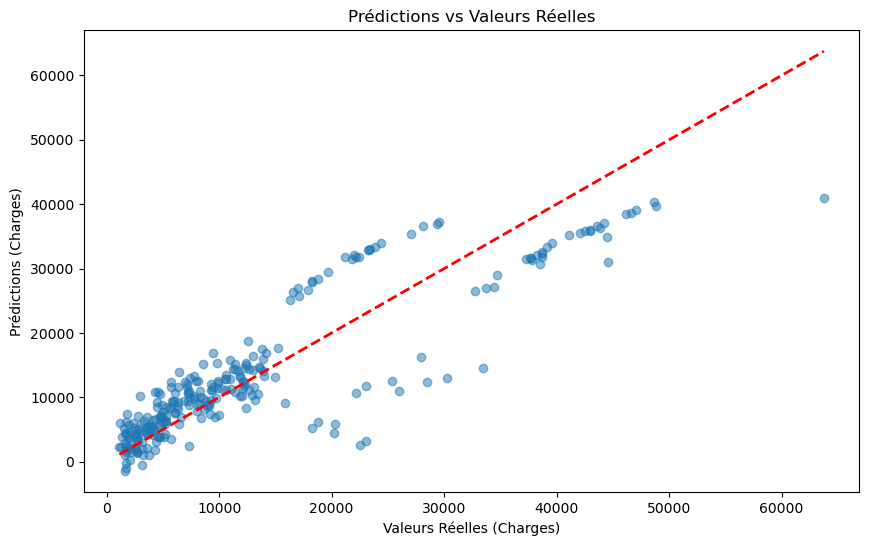

In [7]:
# Visualisation des prédictions vs valeurs réelles
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valeurs Réelles (Charges)')
plt.ylabel('Prédictions (Charges)')
plt.title('Prédictions vs Valeurs Réelles')
plt.show()